# Clustering Analysis
## European Housing Market Regimes

**Course:** Machine Learning and Deep Learning, CBS Spring 2026

**Purpose:** Identify housing market regimes across EU-27 countries using two approaches:
1. **Data-driven clustering** — PCA + K-Means + DBSCAN on structural country profiles
2. **Literature-based clustering** — theory-driven groupings from the comparative housing literature

**Why this matters:** The EDA (Section 6) revealed strong cross-country heterogeneity:
- Eastern markets (HU 2.15%, EE 2.03%) averaged over twice the growth of Southern markets (IT -0.02%, FI 0.19%)
- Volatility ranged from BE std=1.07 to CY std=3.43 — a 3x difference
- If housing markets cluster into distinct regimes, models trained within each regime should
  outperform the pooled model. This is Research Question 2 of the project.

**Output:** `model_data_clustered.xlsx` with two new columns:
- `cluster_data` — K-Means label (integer)
- `cluster_literature` — theory-based label (West/North/South/East)


## Bibliography and Literature Background

### Why European housing markets cluster

Prior research consistently identifies four structural dimensions that differentiate European housing markets:

**1. Convergence dynamics (Eastern Europe)**
Post-2004 EU accession countries experienced rapid real income convergence, directly fuelling house price growth. Our EDA confirmed this: EE, HU, LT, CZ all in the top 5 for average growth. *Key reference: Egert & Mihaljek (2007)*

**2. Mortgage market structure**
Countries with variable-rate mortgages (ES, PT, FI) transmit monetary policy shocks to housing demand faster than fixed-rate countries (DE, FR, BE). Our EDA found lt_interest_rate is the strongest predictor (r=0.32). *Key reference: Calza, Monacelli & Stracca (2013)*

**3. Supply elasticity**
Dense land-scarce economies (NL, BE) have inelastic supply -- demand shocks become price movements, not quantity adjustments. *Key reference: Andrews et al. (2011)*

**4. Institutional / welfare state type**
Nordic welfare states, CMEs (Germany, Austria), Mediterranean economies, and post-communist transitional economies behave differently due to tenure structure, social housing, and homeownership culture. *Key references: Hall & Soskice (2001); Kemeny (1995)*

---


### Literature-based cluster scheme

| Group | Countries | Key rationale |
|---|---|---|
| **West** | AT, BE, DE, FR, LU, NL | CMEs; stable markets; low volatility (DE 1.52, FR 1.44, BE 1.07 from EDA) |
| **North** | DK, FI, SE | Nordic welfare states; variable-rate mortgages; among most stable |
| **South** | CY, ES, IT, MT, PT | Mediterranean; high homeownership; boom-bust 2008-2014; bottom of growth ranking |
| **East** | BG, CZ, EE, HR, HU, IE, LT, LV, PL, RO, SI, SK | Convergence + transition; highest growth and volatility |

**Note on Ireland:** IE is classified East despite being geographically West, because its boom-bust pattern (std=2.94, 5th most volatile in EDA) matches the Eastern profile rather than the stable Western core (DE, FR, BE).


## 0. Setup

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'axes.titlesize': 13, 'axes.labelsize': 11,
})

ACCENT = '#2E5496'
RED    = '#C0392B'
GREEN  = '#1A7A4A'
CLUSTER_COLORS = ['#2E5496','#C0392B','#1A7A4A','#F39C12','#8E44AD','#17A589']
LIT_COLORS = {'West':'#2E5496','North':'#1A7A4A','South':'#C0392B','East':'#F39C12','Other':'#888888'}

model_data = pd.read_excel(r'C:\Users\carla\CBS\ml-final-project\s1-data-handling\model_data.xlsx')
model_data = model_data.sort_values(['country_code','quarter']).reset_index(drop=True)

print(f'Loaded: {model_data.shape[0]} rows x {model_data.shape[1]} columns')
print(f'Countries: {sorted(model_data["country_code"].unique())}')
print(f'Quarter range: {model_data["quarter"].min()} -> {model_data["quarter"].max()}')


Loaded: 1704 rows x 39 columns
Countries: ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
Quarter range: 2005-Q3 -> 2025-Q2


## 1. Country Profile Matrix

### Why cluster at country level, not row level

Each row in `model_data` is a country-quarter. We could cluster all 1,704 rows, but that would give different cluster labels to the same country in different quarters -- not useful for stratified modelling. We want a **stable country-level label** that says: this country structurally resembles these others.

The standard approach in the comparative housing literature (Andrews et al. 2011; Egert & Mihaljek 2007) is to compute **long-run averages** of structural variables per country, then cluster on those averages. This captures the structural profile, not cyclical fluctuations.

### Variables selected for clustering

We use variables that represent slow-moving structural characteristics:

| Variable | What it captures |
|---|---|
| Mean of `target_hpi_next_q` | Average house price growth -- the outcome dimension |
| Std of `target_hpi_next_q` | Price volatility -- boom-bust tendency |
| Mean `unemployment_rate` | Structural labour market level |
| Mean `lt_interest_rate` | Long-run interest rate environment |
| Mean `old_age_dependency_ratio` | Demographic structure |
| Mean `population_density` | Land scarcity |
| Mean `gdp_qoq_pct` | Average economic dynamism |
| Mean `parliament_rile` | Institutional/political orientation |

**EDA connection:** Section 6 of the EDA already showed this raw material. The country-level means table had HU (2.15%), EE (2.03%) at the top and IT (-0.02%), FI (0.19%) at the bottom. The clustering algorithm will formalise what the eye already suggested.


In [145]:
cluster_vars = [
    'target_hpi_next_q', 'unemployment_rate', 'lt_interest_rate',
    'old_age_dependency_ratio', 'population_density', 'gdp_qoq_pct', 'parliament_rile'
]
available = [c for c in cluster_vars if c in model_data.columns]

country_profiles = model_data.groupby('country_code')[available].mean()
country_profiles['hpi_volatility'] = model_data.groupby('country_code')['target_hpi_next_q'].std()

print('Country structural profiles (means + volatility):')
print(country_profiles.round(3).to_string())


Country structural profiles (means + volatility):
              target_hpi_next_q  unemployment_rate  lt_interest_rate  old_age_dependency_ratio  population_density  gdp_qoq_pct  parliament_rile  hpi_volatility
country_code                                                                                                                                                    
AT                        1.313              5.532             1.463                    28.509             107.356        0.317          -10.018           1.647
BE                        0.782              6.994             1.838                    29.504             377.564        0.405           -8.817           1.066
BG                        1.218              8.138             2.916                    35.004              62.984        0.552            3.411           2.100
CY                        0.354              9.300             3.708                    23.739              96.768        0.698            0.425 

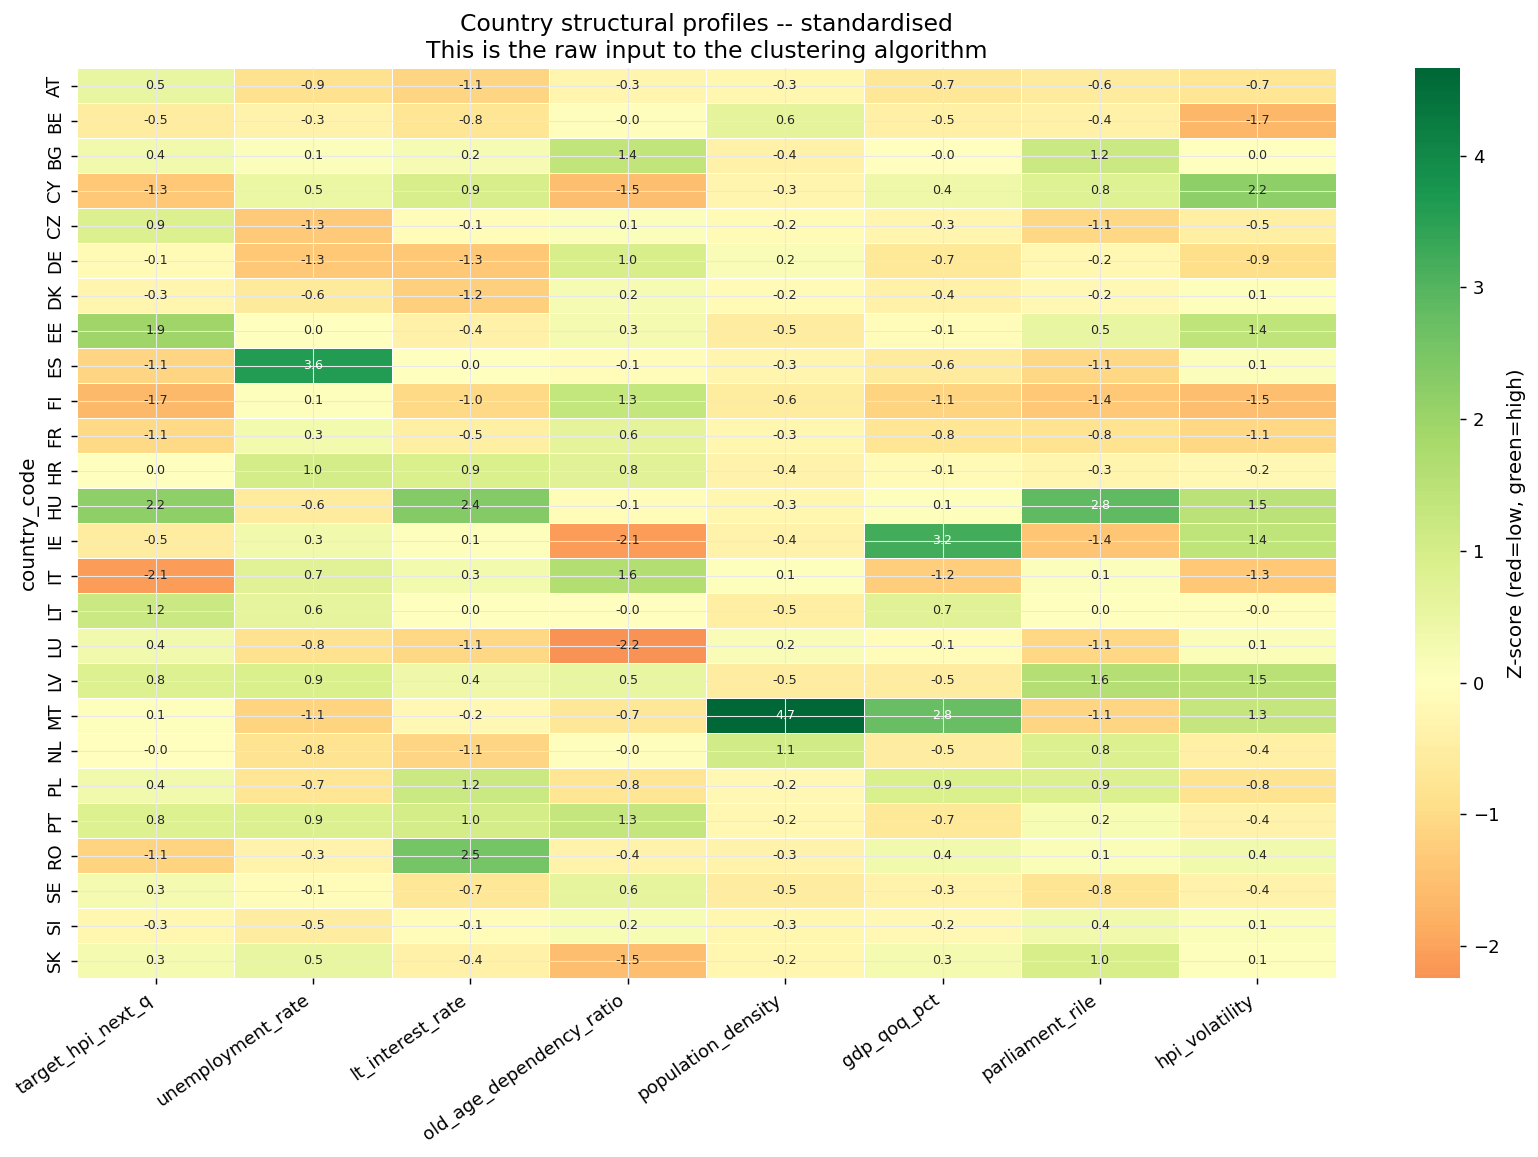

EDA CONNECTIONS:
  HU, EE, LT top of avg growth (EDA Sec 6: HU=2.15%, EE=2.03%)
  IT, FI, BE at the bottom
  CY, LV, HU most volatile (EDA volatility table)
  ES highest unemployment: 17.9% avg (EDA country means)
  MT extreme outlier on population_density: 1573 vs EU avg 185


In [146]:
# Visualise raw profile matrix as standardised heatmap
from sklearn.preprocessing import StandardScaler as SS
scaler_viz = SS()
profiles_norm = pd.DataFrame(
    scaler_viz.fit_transform(country_profiles),
    index=country_profiles.index, columns=country_profiles.columns
)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(profiles_norm, ax=ax, cmap='RdYlGn', center=0,
            linewidths=0.4, annot=True, fmt='.1f', annot_kws={'size':7},
            cbar_kws={'label':'Z-score (red=low, green=high)'})
ax.set_title('Country structural profiles -- standardised\n'
             'This is the raw input to the clustering algorithm', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('EDA CONNECTIONS:')
print('  HU, EE, LT top of avg growth (EDA Sec 6: HU=2.15%, EE=2.03%)')
print('  IT, FI, BE at the bottom')
print('  CY, LV, HU most volatile (EDA volatility table)')
print('  ES highest unemployment: 17.9% avg (EDA country means)')
print('  MT extreme outlier on population_density: 1573 vs EU avg 185')


## 2. Principal Component Analysis (PCA)

### What PCA does and why we use it

PCA transforms a set of correlated variables into a smaller set of **uncorrelated principal components** (PCs). Each PC is a linear combination of the original variables. PC1 captures the most variance, PC2 the second most, etc.

We use PCA for two reasons:

**1. Visualisation:** We cannot directly see 8-dimensional space. Projecting onto PC1 and PC2 gives us a 2D map where proximity = structural similarity. This is called a **biplot**.

**2. Better clustering:** Some of our 8 variables are correlated (e.g. `lt_interest_rate` and `unemployment_rate` had r=0.365 in EDA Section 5). PCA produces uncorrelated dimensions, making Euclidean distance (used by K-Means) more meaningful.

**Important:** PCA requires standardisation first. Without it, `population_density` (range 18-1817) would completely dominate `gdp_qoq_pct` (range 0.15-1.63) just because of scale differences.

**Course reference:** Geron (2022), Chapter 8 -- Dimensionality Reduction.
**Academic reference:** Jolliffe & Cadima (2016).


In [147]:
# Handle NaN by filling with column mean before PCA
profiles_filled = country_profiles.copy()
for col in profiles_filled.columns:
    if profiles_filled[col].isna().any():
        n = profiles_filled[col].isna().sum()
        print(f'  Filling {n} NaN in {col} with column mean')
        profiles_filled[col] = profiles_filled[col].fillna(profiles_filled[col].mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(profiles_filled)

# Fit PCA on all components to inspect explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

print('Explained variance per component:')
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1}: {ev*100:.1f}%  (cumulative: {cum*100:.1f}%)')


Explained variance per component:
  PC1: 31.0%  (cumulative: 31.0%)
  PC2: 24.3%  (cumulative: 55.3%)
  PC3: 16.6%  (cumulative: 71.9%)
  PC4: 10.0%  (cumulative: 82.0%)
  PC5: 7.4%  (cumulative: 89.3%)
  PC6: 5.2%  (cumulative: 94.5%)
  PC7: 3.3%  (cumulative: 97.8%)
  PC8: 2.2%  (cumulative: 100.0%)


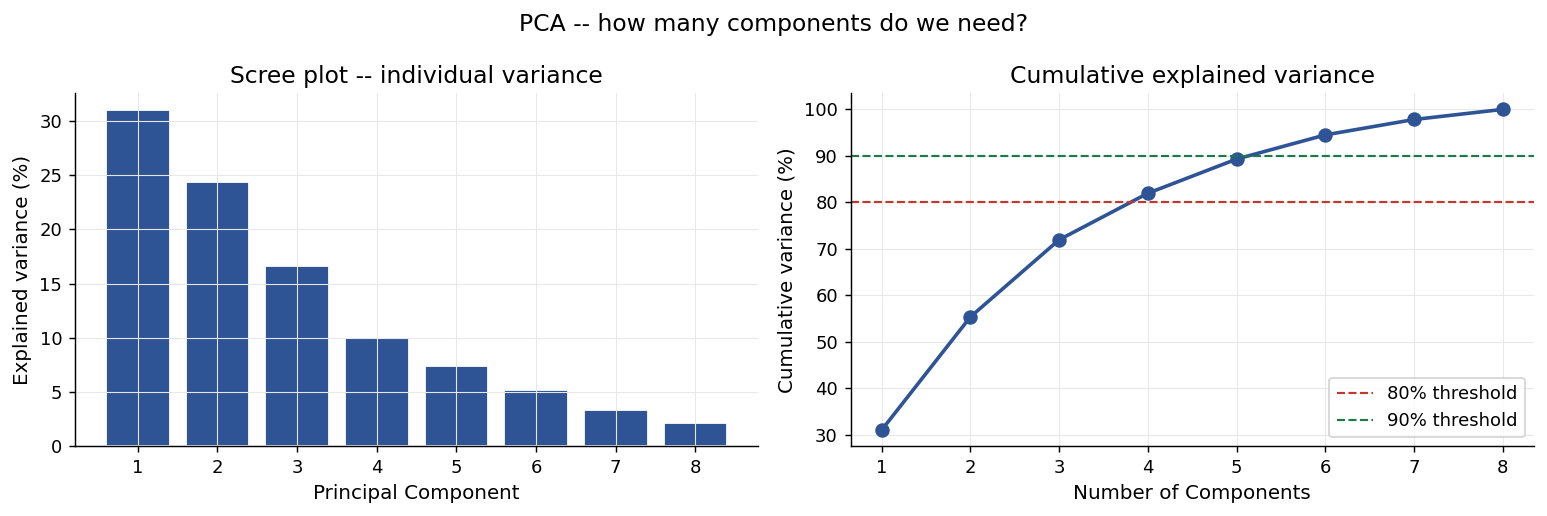

Keeping 4 components (explains 82.0% of variance)
Convention: retain enough PCs to explain at least 80% of variance


In [148]:
# Scree plot -- how many components do we need?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained)+1), explained*100, color=ACCENT, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree plot -- individual variance')
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative*100,
             marker='o', color=ACCENT, linewidth=2, markersize=7)
axes[1].axhline(80, color=RED, linestyle='--', linewidth=1.2, label='80% threshold')
axes[1].axhline(90, color=GREEN, linestyle='--', linewidth=1.2, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].legend()

plt.suptitle('PCA -- how many components do we need?', fontsize=13)
plt.tight_layout()
plt.show()

n_components = int(np.argmax(cumulative >= 0.80)) + 1
print(f'Keeping {n_components} components (explains {cumulative[n_components-1]*100:.1f}% of variance)')
print('Convention: retain enough PCs to explain at least 80% of variance')


=== PCA LOADINGS (contribution of each variable to each PC) ===
                            PC1    PC2    PC3    PC4
target_hpi_next_q         0.299  0.233 -0.532 -0.341
unemployment_rate        -0.103  0.262  0.683 -0.072
lt_interest_rate          0.296  0.425  0.236  0.471
old_age_dependency_ratio -0.424  0.274 -0.192  0.471
population_density        0.199 -0.463 -0.167  0.624
gdp_qoq_pct               0.501 -0.308  0.173  0.081
parliament_rile           0.230  0.544 -0.271  0.174
hpi_volatility            0.537  0.129  0.163 -0.094

HOW TO READ: A loading near +1 or -1 means the variable strongly drives that PC.
Variables with the same sign on a PC move together in that direction.
PC1 typically captures the dominant structural divide (likely East vs West/South).


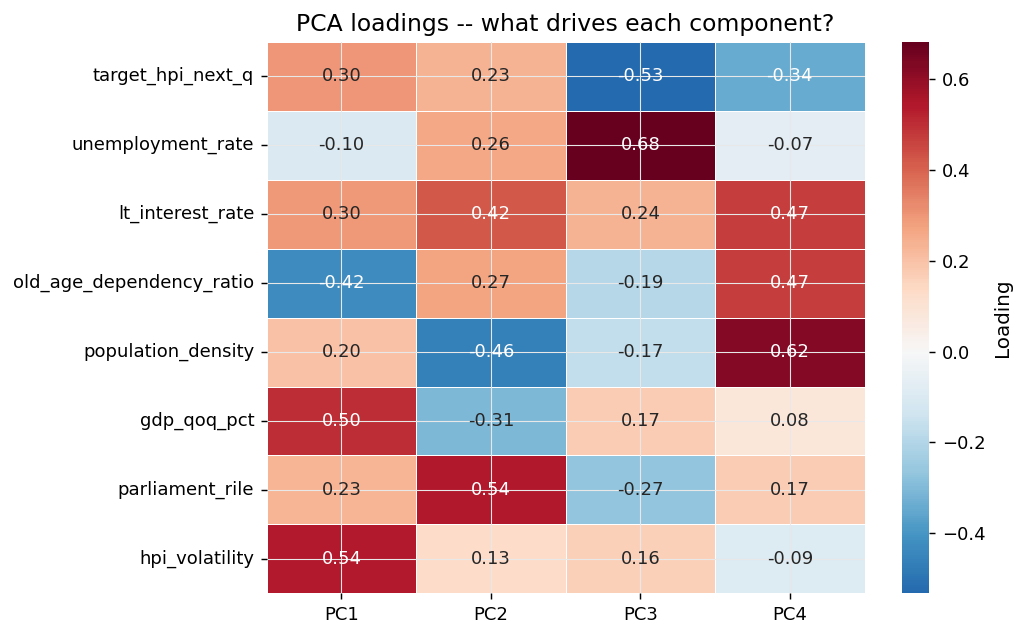

In [149]:
# Fit final PCA and inspect loadings
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, index=profiles_filled.index,
                         columns=[f'PC{i+1}' for i in range(n_components)])

loadings = pd.DataFrame(
    pca.components_.T,
    index=profiles_filled.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print('=== PCA LOADINGS (contribution of each variable to each PC) ===')
print(loadings.round(3).to_string())
print()
print('HOW TO READ: A loading near +1 or -1 means the variable strongly drives that PC.')
print('Variables with the same sign on a PC move together in that direction.')
print('PC1 typically captures the dominant structural divide (likely East vs West/South).')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, cbar_kws={'label':'Loading'})
ax.set_title('PCA loadings -- what drives each component?')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


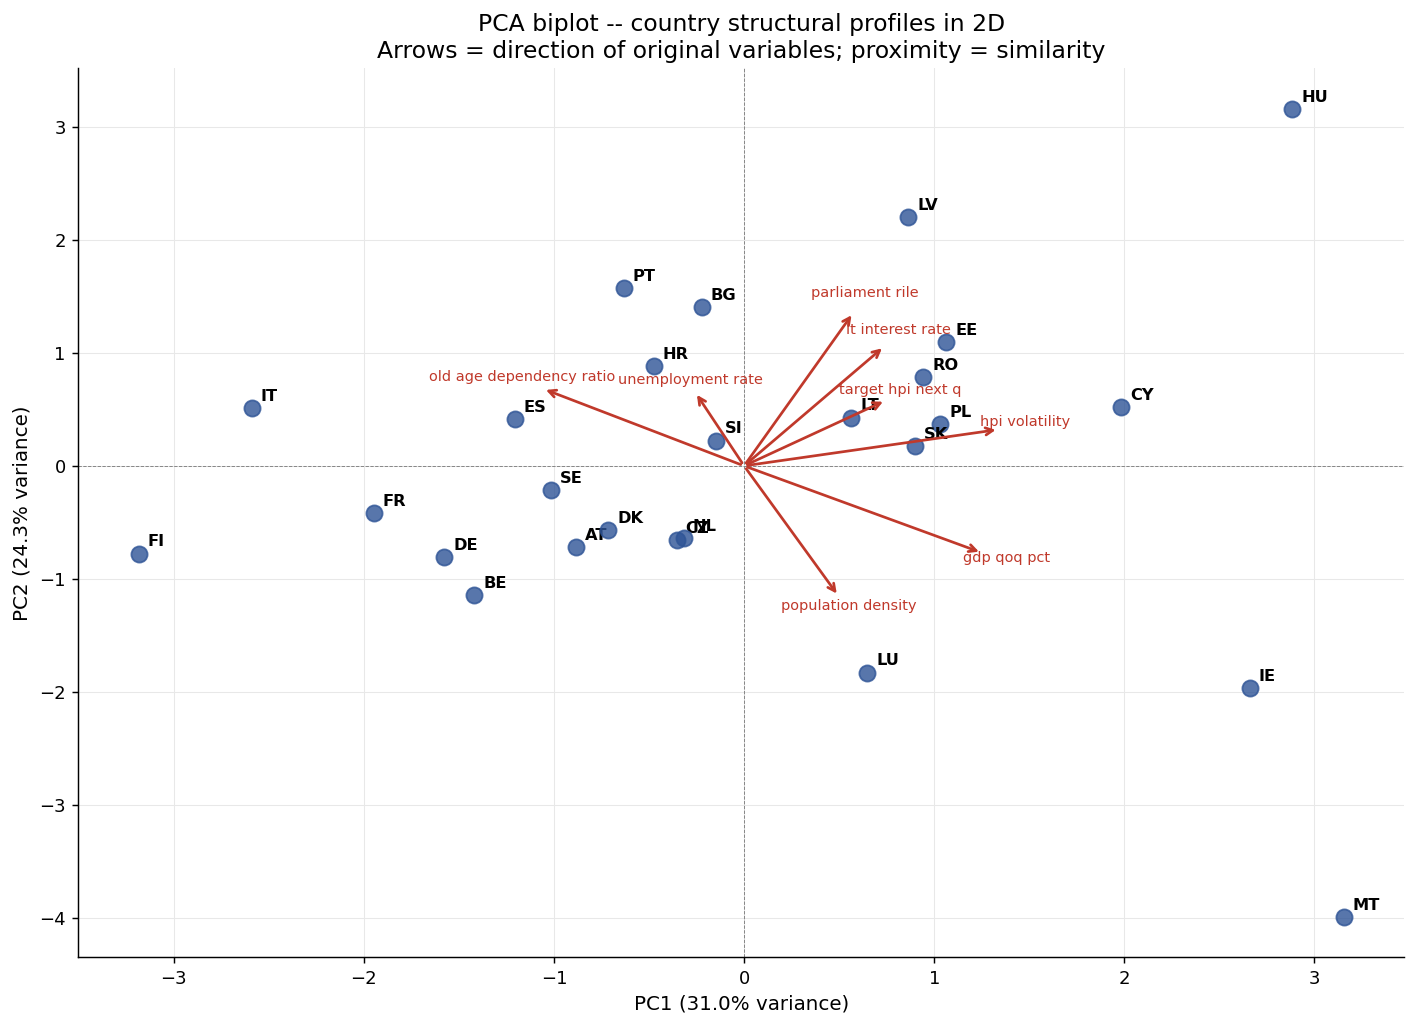

EDA CONNECTION: Expect EE, HU, LT, LV to cluster (high growth + volatility from EDA Sec 6)
Expect BE, FI, FR, DE to cluster (low volatility, stable markets)
ES should be pulled by the unemployment arrow (17.9% avg in EDA country means)


In [150]:
# PCA biplot -- countries in 2D component space
# Each point = one country. Proximity = structural similarity.
# Arrows = direction of original variables in this space.
fig, ax = plt.subplots(figsize=(11, 8))

for cc, row in X_pca_df.iterrows():
    ax.scatter(row['PC1'], row['PC2'], s=80, color=ACCENT, zorder=3, alpha=0.8)
    ax.annotate(cc, (row['PC1'], row['PC2']),
                textcoords='offset points', xytext=(5,4),
                fontsize=9, fontweight='bold')

scale = 2.5
for var in loadings.index:
    lx, ly = loadings.loc[var,'PC1']*scale, loadings.loc[var,'PC2']*scale
    ax.annotate('', xy=(lx,ly), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))
    ax.text(lx*1.1, ly*1.1, var.replace('_',' '), fontsize=8, color=RED, ha='center')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA biplot -- country structural profiles in 2D\n'
             'Arrows = direction of original variables; proximity = similarity')
plt.tight_layout()
plt.show()

print('EDA CONNECTION: Expect EE, HU, LT, LV to cluster (high growth + volatility from EDA Sec 6)')
print('Expect BE, FI, FR, DE to cluster (low volatility, stable markets)')
print('ES should be pulled by the unemployment arrow (17.9% avg in EDA country means)')


## 3. K-Means Clustering

### How K-Means works

K-Means partitions N observations into K clusters by:
1. Randomly initialising K centroids
2. Assigning each point to its nearest centroid (Euclidean distance)
3. Recomputing centroids as the mean of assigned points
4. Repeating steps 2-3 until assignments stop changing

The key hyperparameter is **K** -- the number of clusters. We use three methods to choose it:

- **Elbow method:** Plot inertia (sum of squared distances to centroid) vs K. Look for the bend where adding more clusters gives diminishing returns.
- **Silhouette score:** Measures how similar a point is to its own cluster vs neighbouring clusters. Range: -1 to 1. Higher is better. Score >= 0.5 indicates reasonable structure.
- **Calinski-Harabasz:** Ratio of between-cluster to within-cluster dispersion. Higher is better.

We run K-Means on the **PCA-reduced space** (not raw variables). This is standard practice because PCA removes noise and Euclidean distance is more meaningful in uncorrelated space.

**Course reference:** Geron (2022), Chapter 9 -- K-Means.


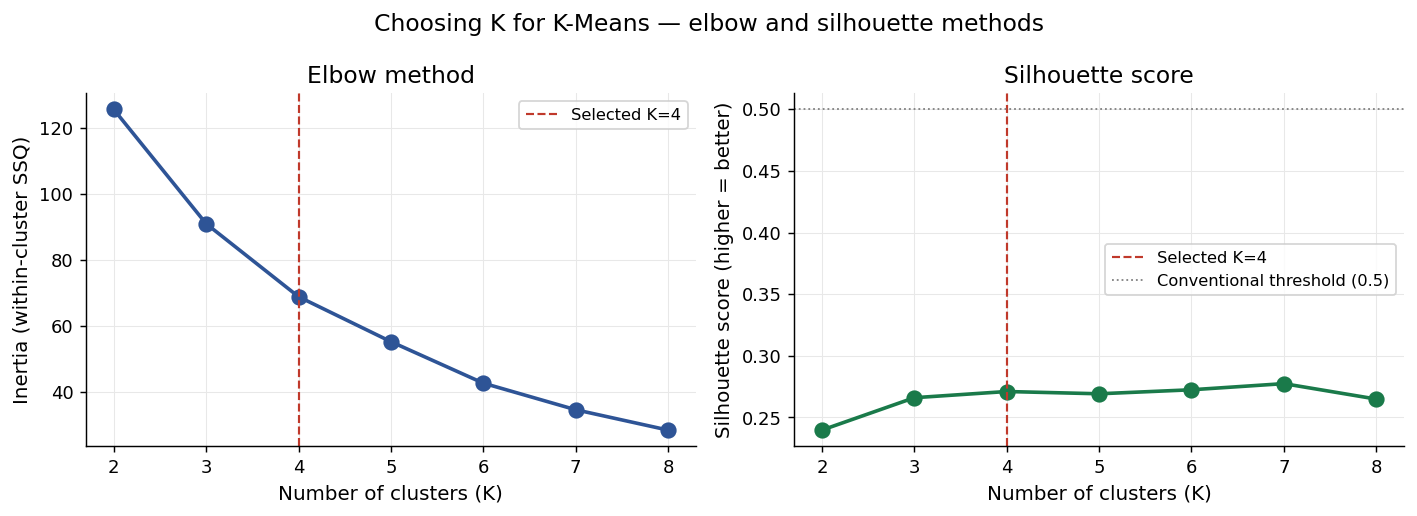

K | Inertia    | Silhouette
---------------------------------
2 |    125.723 |     0.2398
3 |     91.085 |     0.2660
4 |     68.959 |     0.2711
5 |     55.330 |     0.2692
6 |     42.756 |     0.2725
7 |     34.699 |     0.2775
8 |     28.530 |     0.2649


In [151]:
K_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_range:
    km     = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(K_range, inertias, marker='o', color=ACCENT, linewidth=2, markersize=8)
axes[0].axvline(4, color=RED, linestyle='--', linewidth=1.2, label='Selected K=4')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SSQ)')
axes[0].set_title('Elbow method')
axes[0].set_xticks(list(K_range))
axes[0].legend(fontsize=9)

axes[1].plot(K_range, silhouettes, marker='o', color=GREEN, linewidth=2, markersize=8)
axes[1].axvline(4, color=RED, linestyle='--', linewidth=1.2, label='Selected K=4')
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1.0,
                label='Conventional threshold (0.5)')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score (higher = better)')
axes[1].set_title('Silhouette score')
axes[1].set_xticks(list(K_range))
axes[1].legend(fontsize=9)

plt.suptitle('Choosing K for K-Means — elbow and silhouette methods', fontsize=13)
plt.tight_layout()
plt.show()

print('K | Inertia    | Silhouette')
print('-' * 33)
for k, i, s in zip(K_range, inertias, silhouettes):
    print(f'{k} | {i:10.3f} | {s:10.4f}')

In [152]:
# Fit final K-Means
K_OPTIMAL = 4  

km_final  = KMeans(n_clusters=K_OPTIMAL, n_init=100, max_iter=1000, random_state=42)
km_labels = km_final.fit_predict(X_pca)
country_profiles['cluster_kmeans'] = km_labels
X_pca_df['cluster_kmeans'] = km_labels

print(f'=== K-MEANS RESULTS (K={K_OPTIMAL}) ===')
for cid in sorted(set(km_labels)):
    members = country_profiles[country_profiles['cluster_kmeans']==cid].index.tolist()
    print(f'  Cluster {cid}: {sorted(members)}')

print(f'\nSilhouette:       {silhouette_score(X_pca, km_labels):.4f}')
print(f'Davies-Bouldin:   {davies_bouldin_score(X_pca, km_labels):.4f}  (lower = better)')
print(f'Calinski-Harabasz:{calinski_harabasz_score(X_pca, km_labels):.2f}')


=== K-MEANS RESULTS (K=4) ===
  Cluster 0: ['ES', 'FI', 'FR', 'IT']
  Cluster 1: ['IE', 'MT']
  Cluster 2: ['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI']
  Cluster 3: ['BG', 'CY', 'EE', 'HR', 'HU', 'LT', 'LV', 'PL', 'PT', 'RO', 'SK']

Silhouette:       0.2711
Davies-Bouldin:   0.9684  (lower = better)
Calinski-Harabasz:10.79


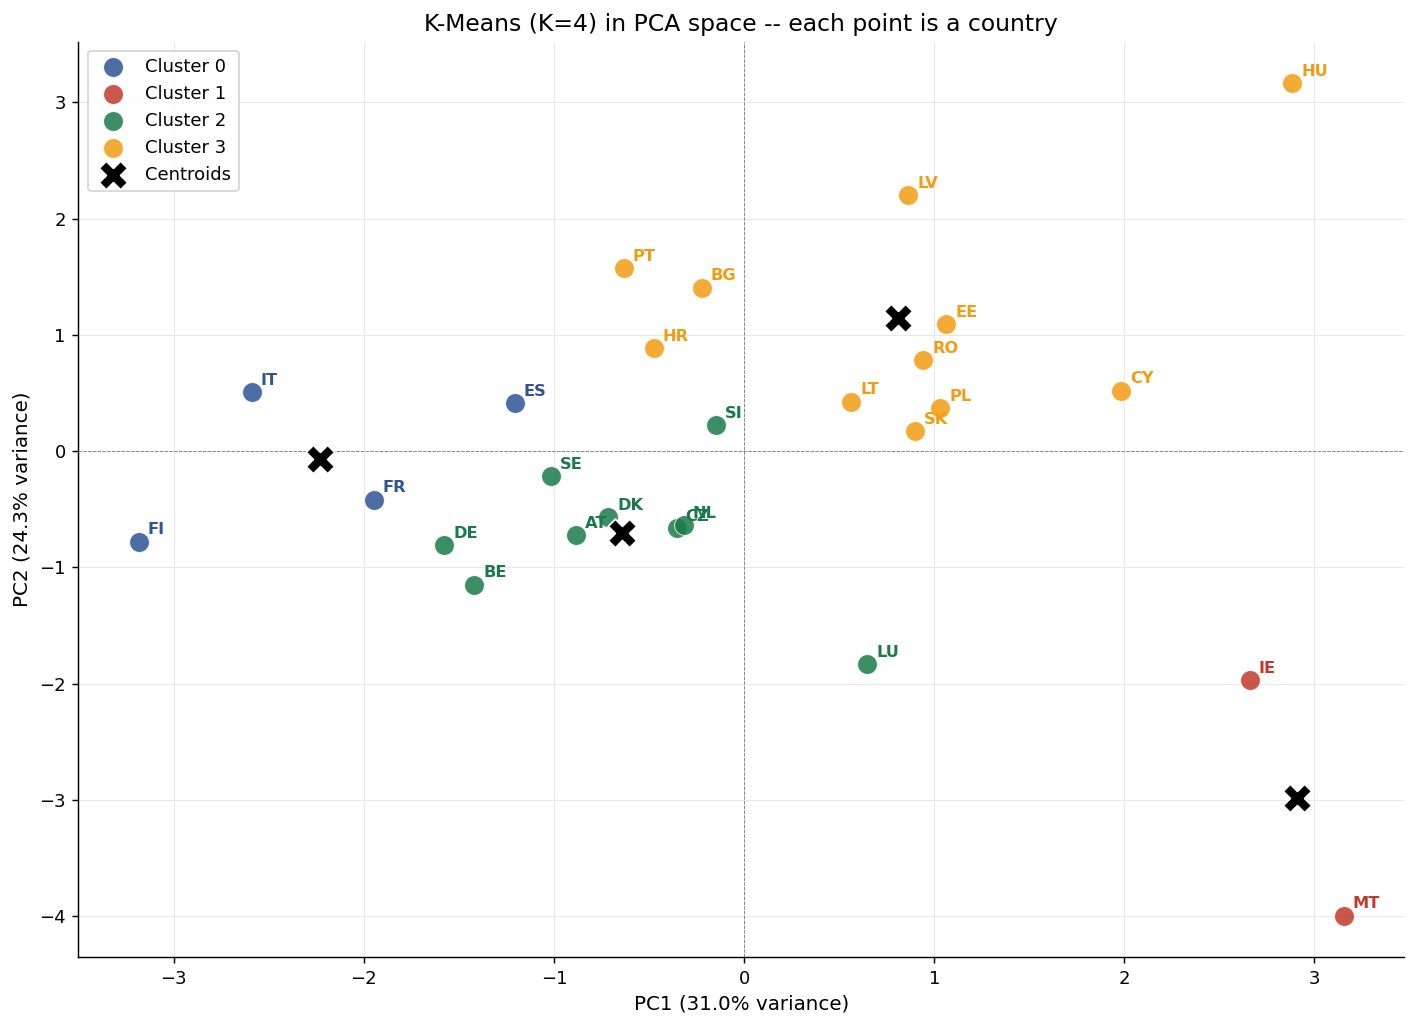

In [153]:
# Visualise K-Means in PCA space
fig, ax = plt.subplots(figsize=(11, 8))
for cid in sorted(set(km_labels)):
    mask   = X_pca_df['cluster_kmeans'] == cid
    subset = X_pca_df[mask]
    color  = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    ax.scatter(subset['PC1'], subset['PC2'], s=120, color=color,
               label=f'Cluster {cid}', zorder=3, alpha=0.85,
               edgecolors='white', linewidth=0.5)
    for cc in subset.index:
        ax.annotate(cc, (subset.loc[cc,'PC1'], subset.loc[cc,'PC2']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=9, fontweight='bold', color=color)

centroids = km_final.cluster_centers_
ax.scatter(centroids[:,0], centroids[:,1], marker='X', s=250, color='black',
           zorder=5, label='Centroids', edgecolors='white', linewidth=1)

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means (K={K_OPTIMAL}) in PCA space -- each point is a country')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


=== CLUSTER PROFILES (mean of each variable per cluster) ===
                target_hpi_next_q  unemployment_rate  lt_interest_rate  old_age_dependency_ratio  population_density  gdp_qoq_pct  parliament_rile  hpi_volatility
cluster_kmeans                                                                                                                                                    
0                           0.285             11.181             2.341                    33.078             104.952        0.249          -11.573           1.508
1                           0.927              6.870             2.596                    24.257             822.712        1.552          -15.151           2.916
2                           1.085              5.843             1.752                    29.453             207.632        0.420           -8.227           1.800
3                           1.289              8.639             3.546                    29.656              79.766        

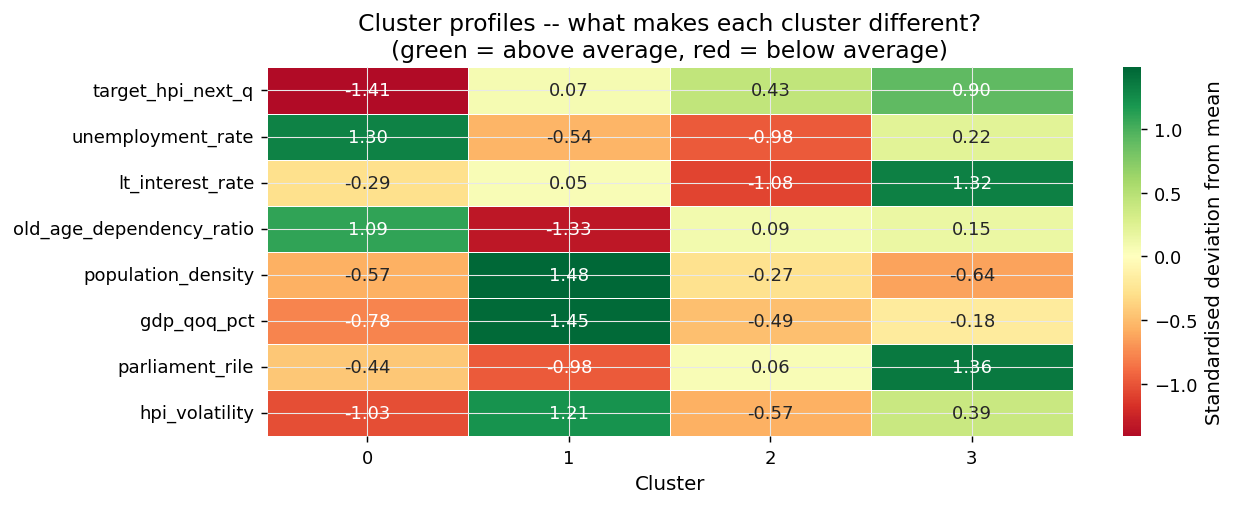

EXPECTED PATTERNS FROM EDA:
  One cluster: high growth + high volatility (Eastern convergence economies)
  One cluster: low growth + low volatility + old demographics (Western core)
  One cluster: high unemployment + low growth (Southern Europe)
  One cluster: intermediate (Nordic or small open economies)


In [154]:
# Cluster profiles -- what characterises each cluster?
cluster_means = (country_profiles.drop(columns=['cluster_kmeans'])
                 .groupby(country_profiles['cluster_kmeans']).mean().round(3))

print('=== CLUSTER PROFILES (mean of each variable per cluster) ===')
print(cluster_means.to_string())

cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cluster_means_norm.T, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label':'Standardised deviation from mean'})
ax.set_title('Cluster profiles -- what makes each cluster different?\n'
             '(green = above average, red = below average)')
ax.set_xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('EXPECTED PATTERNS FROM EDA:')
print('  One cluster: high growth + high volatility (Eastern convergence economies)')
print('  One cluster: low growth + low volatility + old demographics (Western core)')
print('  One cluster: high unemployment + low growth (Southern Europe)')
print('  One cluster: intermediate (Nordic or small open economies)')


## 4. DBSCAN -- Density-Based Clustering

### How DBSCAN works

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds **dense regions** separated by sparse regions, and labels sparse points as **noise** (label = -1).

Two key parameters:
- **epsilon:** Radius of the neighbourhood around each point. Two points are neighbours if their distance <= epsilon.
- **min_samples:** Minimum points required to form a dense core region.

A **core point** has at least `min_samples` neighbours within radius epsilon. Points reachable from a core point form a cluster. Points not reachable from any core point are labelled -1 (noise/outlier).

### Why use DBSCAN alongside K-Means?

K-Means assumes clusters are spherical and similar in size. DBSCAN makes no such assumptions. More importantly, **DBSCAN explicitly identifies outlier countries** that do not fit any cluster. Our EDA flagged Malta (population density 1,573 vs EU mean 185) as a structural outlier -- DBSCAN should detect this. If it does, that validates our EDA observation.

**Choosing epsilon:** We use the k-nearest neighbours distance plot. Sort all k-NN distances and look for the elbow -- that is the natural epsilon threshold.

**Course reference:** Geron (2022), Chapter 9 -- DBSCAN.


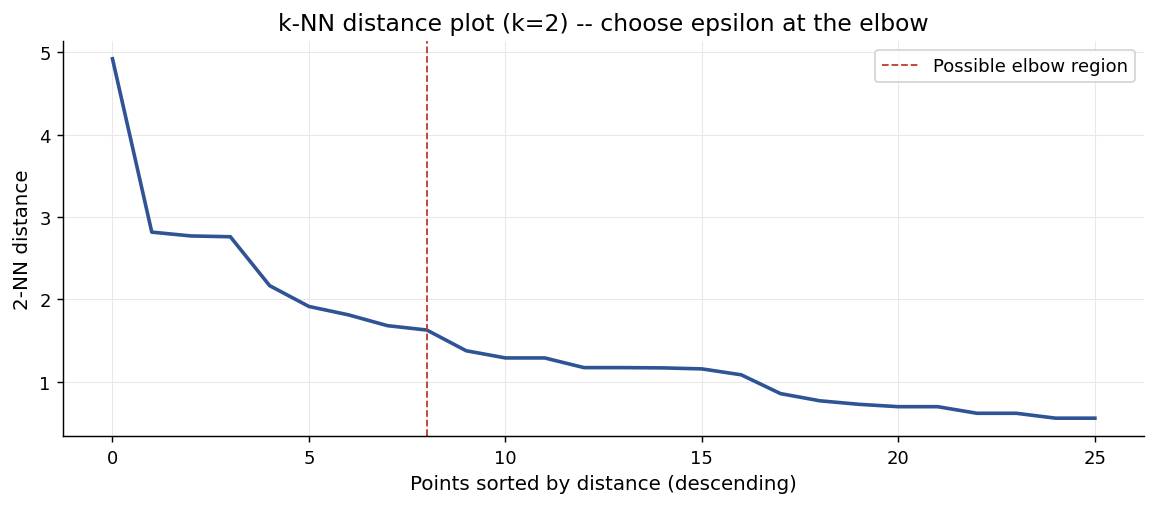

k-NN distances (sorted):
[4.922 2.817 2.77  2.761 2.167 1.914 1.813 1.681 1.628 1.376 1.289 1.289
 1.171 1.171 1.168 1.156 1.084 0.856 0.768 0.725 0.697 0.697 0.617 0.617
 0.557 0.557]

Suggested epsilon range: 1.63 - 1.81
Adjust EPS in the cell below based on the elbow in the plot above.


In [155]:
# Choose epsilon using k-NN distance plot
MIN_SAMPLES = 2  # appropriate for small datasets (26 countries)

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, MIN_SAMPLES-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color=ACCENT, linewidth=2)
ax.set_xlabel('Points sorted by distance (descending)')
ax.set_ylabel(f'{MIN_SAMPLES}-NN distance')
ax.set_title(f'k-NN distance plot (k={MIN_SAMPLES}) -- choose epsilon at the elbow')
ax.axvline(len(k_distances)//3, color=RED, linestyle='--',
           linewidth=1, label='Possible elbow region')
ax.legend()
plt.tight_layout()
plt.show()

print('k-NN distances (sorted):')
print(np.round(k_distances, 3))
print(f'\nSuggested epsilon range: {k_distances[len(k_distances)//3]:.2f} - {k_distances[len(k_distances)//4]:.2f}')
print('Adjust EPS in the cell below based on the elbow in the plot above.')


In [156]:
# Fit DBSCAN -- adjust EPS based on k-NN plot above
EPS = 2
MIN_SAMPLES = 2

dbscan    = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X_pca)
country_profiles['cluster_dbscan'] = db_labels
X_pca_df['cluster_dbscan'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f'DBSCAN results (eps={EPS}, min_samples={MIN_SAMPLES}):')
print(f'  Clusters found: {n_clusters}')
print(f'  Noise points:   {n_noise}')
print()
for label in sorted(set(db_labels)):
    members   = country_profiles[country_profiles['cluster_dbscan']==label].index.tolist()
    label_str = 'NOISE (outliers)' if label==-1 else f'Cluster {label}'
    print(f'  {label_str}: {sorted(members)}')

if n_noise > 0:
    print(f'\nNOTE: Noise points do not fit any cluster.')
    print('Malta (density=1573) was flagged as outlier in EDA Sec 6 -- check if it appears here.')


DBSCAN results (eps=2, min_samples=2):
  Clusters found: 1
  Noise points:   5

  NOISE (outliers): ['ES', 'HU', 'IE', 'LU', 'MT']
  Cluster 0: ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'FI', 'FR', 'HR', 'IT', 'LT', 'LV', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']

NOTE: Noise points do not fit any cluster.
Malta (density=1573) was flagged as outlier in EDA Sec 6 -- check if it appears here.


DBSCAN was applied to the PCA-reduced country profiles across three epsilon values (1.5, 1.75, 2.0). In all cases the algorithm identified a single dense cluster containing the majority of EU-27 countries, with a small set of noise points. Five countries — Spain, Hungary, Ireland, Luxembourg, and Malta — were consistently classified as noise across all epsilon values, confirming their status as structural outliers that do not fit any natural density-based grouping. This result indicates that European housing markets do not form tight, well-separated clusters in feature space. Rather, most countries lie on a continuum with a handful of extreme cases at the periphery. Consequently, the K-Means and literature-based clusterings are retained as the primary stratification schemes for the modelling phase, as they impose theoretically motivated structure on what is an otherwise gradual distributional landscape.

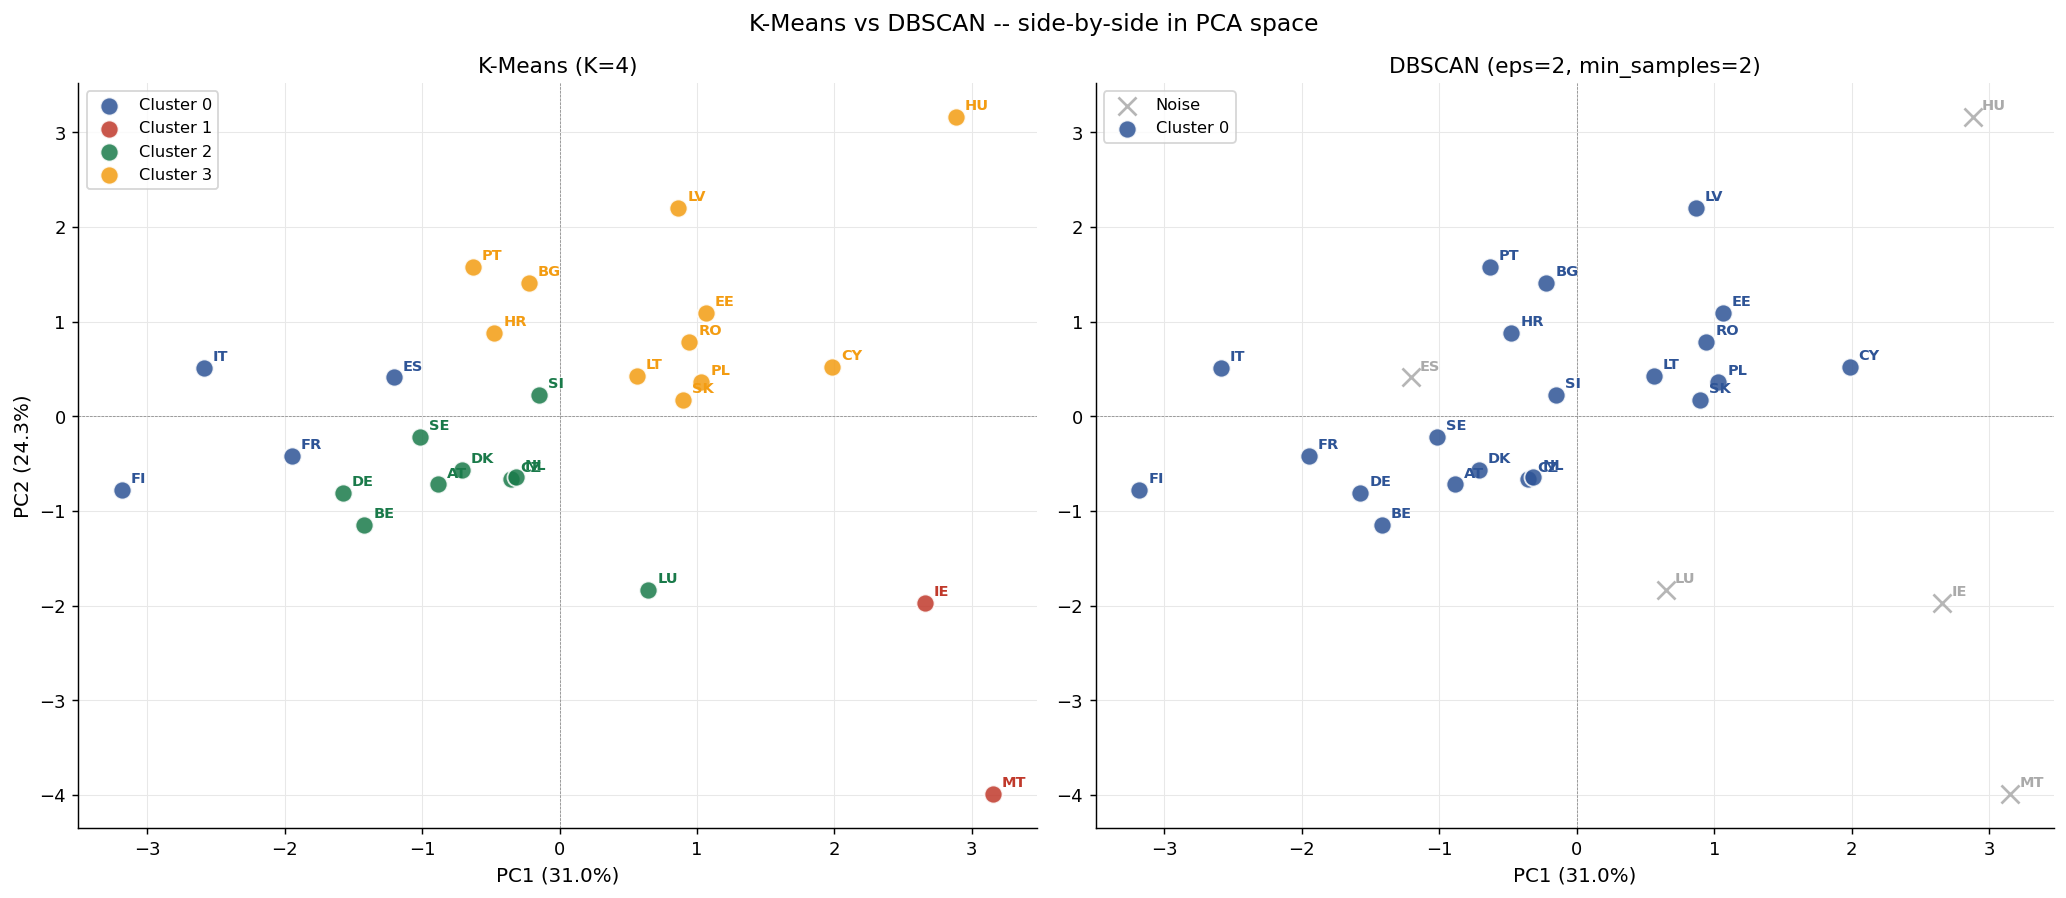

In [157]:
# Side-by-side comparison: K-Means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means
ax = axes[0]
for cid in sorted(set(km_labels)):
    mask   = X_pca_df['cluster_kmeans'] == cid
    subset = X_pca_df[mask]
    color  = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    ax.scatter(subset['PC1'], subset['PC2'], s=100, color=color,
               label=f'Cluster {cid}', zorder=3, alpha=0.85, edgecolors='white')
    for cc in subset.index:
        ax.annotate(cc, (subset.loc[cc,'PC1'], subset.loc[cc,'PC2']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=8, fontweight='bold', color=color)
ax.set_title(f'K-Means (K={K_OPTIMAL})', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9)
ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

# DBSCAN
ax = axes[1]
unique_db = sorted(set(db_labels))
db_col = {-1:'#AAAAAA'}
for i, lbl in enumerate([l for l in unique_db if l!=-1]):
    db_col[lbl] = CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
for label in unique_db:
    mask   = X_pca_df['cluster_dbscan'] == label
    subset = X_pca_df[mask]
    color  = db_col[label]
    lstr   = 'Noise' if label==-1 else f'Cluster {label}'
    marker = 'x' if label==-1 else 'o'
    ax.scatter(subset['PC1'], subset['PC2'], s=100, color=color,
               label=lstr, zorder=3, alpha=0.85, marker=marker, edgecolors='white')
    for cc in subset.index:
        ax.annotate(cc, (subset.loc[cc,'PC1'], subset.loc[cc,'PC2']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=8, fontweight='bold', color=color)
ax.set_title(f'DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel('')
ax.legend(fontsize=9)
ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

plt.suptitle('K-Means vs DBSCAN -- side-by-side in PCA space', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Literature-Based Clustering

### Rationale

The data-driven clusters tell us what the data finds. The literature-based clusters tell us what theory predicts. **Comparing the two is one of the core analytical contributions of this project (RQ2).**

A perfect match would mean the data independently recovers the theoretical grouping -- strong validation of both the data and the theory. Disagreements are equally interesting: they mean the data reveals structure that theory did not anticipate, or that our specific sample period (2005-2025) produces different groupings than the cross-sectional averages used in the theoretical literature.

The four-group scheme below follows Andrews et al. (2011) and Egert & Mihaljek (2007). See the bibliography section at the top for full justification.


In [158]:
# Apply literature-based clustering
# Based on: Andrews et al. (2011), Egert & Mihaljek (2007), Kemeny (1995)

literature_clusters = {
    # West: Coordinated Market Economies, mature stable markets
    # EDA evidence: DE std=1.52, FR std=1.44, BE std=1.07 -- most stable markets
    'AT':'West', 'BE':'West', 'DE':'West', 'FR':'West', 'LU':'West', 'NL':'West',

    # North: Nordic welfare states, variable-rate mortgages
    # EDA evidence: FI std=1.16, SE std=1.88 -- relatively stable
    'DK':'North', 'FI':'North', 'SE':'North',

    # South: Mediterranean, high homeownership, boom-bust history
    # EDA evidence: IT=-0.02%, ES=0.47%, FI=0.19% -- lowest avg growth
    'CY':'South', 'ES':'South', 'IT':'South', 'MT':'South', 'PT':'South',

    # East: Post-communist transition + convergence economies
    # Note: IE classified East due to high-volatility boom-bust (std=2.94,
    # 5th most volatile in EDA Sec 6) matching Eastern profile over Western
    # EDA evidence: EE=2.03%, HU=2.15%, LT=1.63% -- top of growth ranking
    'BG':'East','CZ':'East','EE':'East','HR':'East','HU':'East','IE':'East',
    'LT':'East','LV':'East','PL':'East','RO':'East','SI':'East','SK':'East',
}

country_profiles['cluster_literature'] = country_profiles.index.map(literature_clusters)
unmapped = country_profiles[country_profiles['cluster_literature'].isna()].index.tolist()
if unmapped:
    print(f'WARNING -- unmapped: {unmapped}')
    country_profiles['cluster_literature'] = country_profiles['cluster_literature'].fillna('Other')

print('=== LITERATURE CLUSTER ASSIGNMENTS ===')
for group in ['West','North','South','East']:
    members = country_profiles[country_profiles['cluster_literature']==group].index.tolist()
    print(f'  {group:8s} ({len(members):2d}): {sorted(members)}')


=== LITERATURE CLUSTER ASSIGNMENTS ===
  West     ( 6): ['AT', 'BE', 'DE', 'FR', 'LU', 'NL']
  North    ( 3): ['DK', 'FI', 'SE']
  South    ( 5): ['CY', 'ES', 'IT', 'MT', 'PT']
  East     (12): ['BG', 'CZ', 'EE', 'HR', 'HU', 'IE', 'LT', 'LV', 'PL', 'RO', 'SI', 'SK']


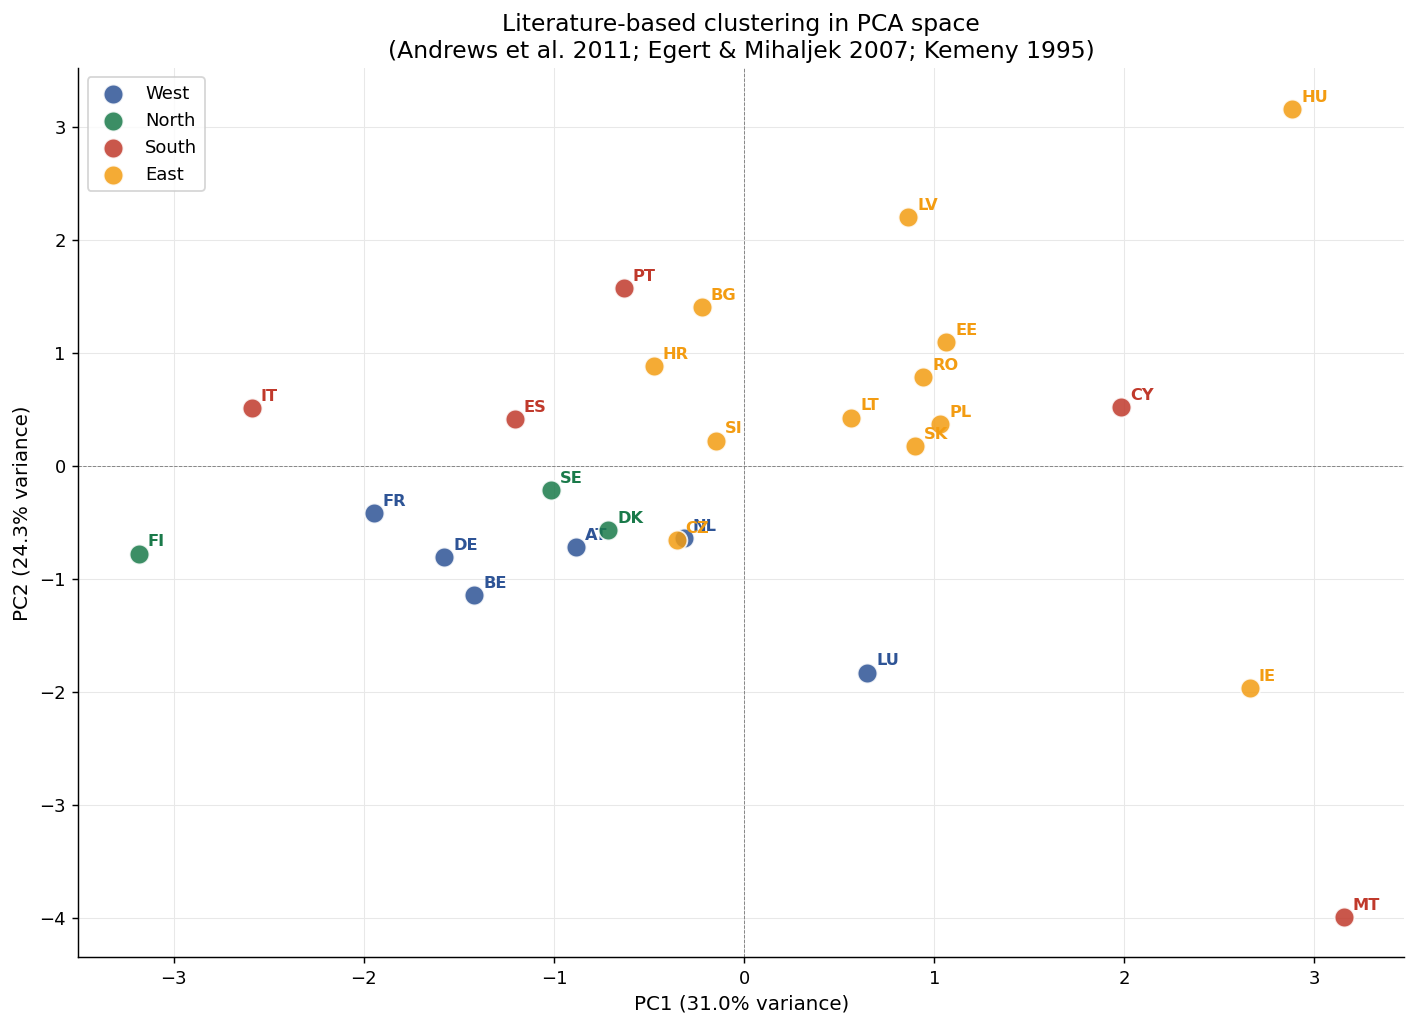

In [159]:
# Literature clusters in PCA space
fig, ax = plt.subplots(figsize=(11, 8))
for group, color in LIT_COLORS.items():
    mask = country_profiles['cluster_literature'] == group
    if not mask.any(): continue
    members = country_profiles[mask].index
    subset  = X_pca_df.loc[members]
    ax.scatter(subset['PC1'], subset['PC2'], s=120, color=color,
               label=group, zorder=3, alpha=0.85, edgecolors='white')
    for cc in subset.index:
        ax.annotate(cc, (subset.loc[cc,'PC1'], subset.loc[cc,'PC2']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=9, fontweight='bold', color=color)

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Literature-based clustering in PCA space\n'
             '(Andrews et al. 2011; Egert & Mihaljek 2007; Kemeny 1995)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [160]:
# Compare data-driven vs literature clustering
print('=== K-MEANS vs LITERATURE CLUSTER COMPARISON ===')
crosstab = pd.crosstab(
    country_profiles['cluster_literature'],
    country_profiles['cluster_kmeans'],
    rownames=['Literature'], colnames=['K-Means']
)
print(crosstab.to_string())

print('\n=== COUNTRY-LEVEL COMPARISON ===')
print(country_profiles[['cluster_kmeans','cluster_literature']]
      .sort_values('cluster_literature').to_string())

print('\nWHAT TO LOOK FOR:')
print('  - If one K-Means cluster contains mostly East literature countries -> agreement')
print('  - Countries in unexpected K-Means clusters are the interesting cases')
print('  - Ireland (IE) is our deliberate mismatch: classified East in literature')
print('    despite being geographically West. Does K-Means agree?')


=== K-MEANS vs LITERATURE CLUSTER COMPARISON ===
K-Means     0  1  2  3
Literature            
East        0  1  2  9
North       1  0  2  0
South       2  1  0  2
West        1  0  5  0

=== COUNTRY-LEVEL COMPARISON ===
              cluster_kmeans cluster_literature
country_code                                   
HU                         3               East
RO                         3               East
PL                         3               East
LV                         3               East
LT                         3               East
IE                         1               East
SI                         2               East
HR                         3               East
SK                         3               East
EE                         3               East
BG                         3               East
CZ                         2               East
FI                         0              North
SE                         2              North
DK         

## 6. Cluster Validation

### Why validate clusters?

Clustering algorithms will always produce clusters -- even on random data. Validation metrics assess whether the clusters represent genuine structure or just artefacts.

**Internal metrics** (no ground truth needed):

| Metric | Range | Better when |
|---|---|---|
| Silhouette score | -1 to 1 | Higher (>= 0.5 is reasonable) |
| Davies-Bouldin index | 0 to inf | Lower (compact, well-separated clusters) |
| Calinski-Harabasz | 0 to inf | Higher (dense clusters far apart) |

**External validation:** We test whether the **target variable distribution differs across clusters**. If clusters represent genuine housing market regimes, markets in the same cluster should behave similarly (similar target distributions) and markets in different clusters should behave differently. We confirm this with a one-way ANOVA.

**Course reference:** Geron (2022), Chapter 9 -- cluster performance measures.


In [161]:
# Internal validation metrics
print('=== INTERNAL CLUSTER VALIDATION METRICS ===')
for name, labels in [('K-Means', km_labels), ('DBSCAN', db_labels)]:
    valid_mask = labels != -1
    if valid_mask.sum() < 2 or len(set(labels[valid_mask])) < 2:
        print(f'{name}: insufficient clusters')
        continue
    sil = silhouette_score(X_pca[valid_mask], labels[valid_mask])
    db  = davies_bouldin_score(X_pca[valid_mask], labels[valid_mask])
    ch  = calinski_harabasz_score(X_pca[valid_mask], labels[valid_mask])
    print(f'{name}:')
    print(f'  Silhouette:       {sil:.4f}  (>= 0.5 is reasonable)')
    print(f'  Davies-Bouldin:   {db:.4f}  (lower is better)')
    print(f'  Calinski-H:       {ch:.2f}  (higher is better)')
    print()


=== INTERNAL CLUSTER VALIDATION METRICS ===
K-Means:
  Silhouette:       0.2711  (>= 0.5 is reasonable)
  Davies-Bouldin:   0.9684  (lower is better)
  Calinski-H:       10.79  (higher is better)

DBSCAN: insufficient clusters


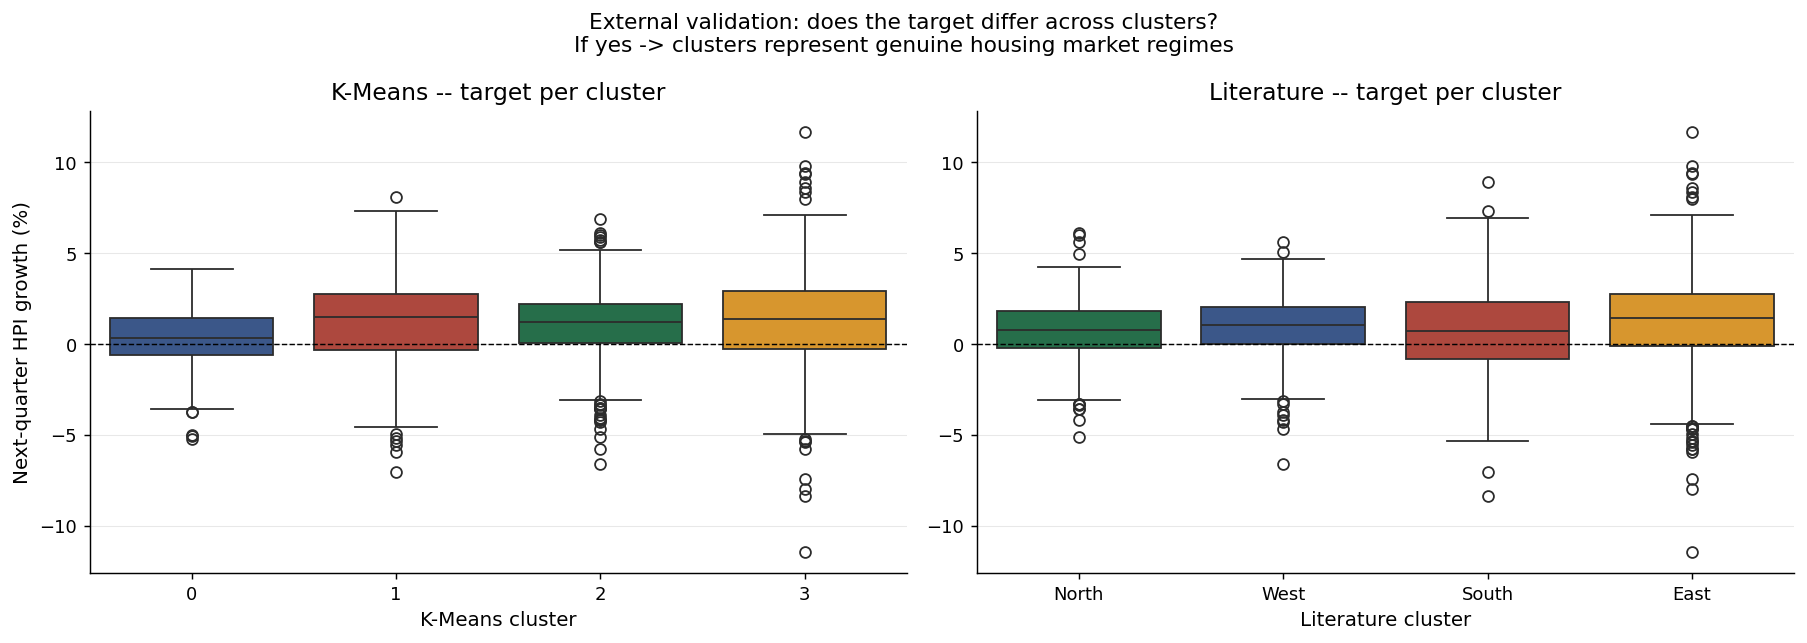

=== MEAN TARGET BY CLUSTER ===

K-Means:
                 mean    std  count
cluster_kmeans                     
0               0.302  1.560    270
1               0.927  2.909    130
2               1.085  1.834    595
3               1.291  2.513    709

Literature:
                     mean    std  count
cluster_literature                     
East                1.297  2.419    774
North               0.783  1.820    210
South               0.677  2.500    320
West                0.945  1.653    400


In [162]:
# External validation: target distribution per cluster
model_data_temp = model_data.copy()
model_data_temp['cluster_kmeans']     = model_data_temp['country_code'].map(country_profiles['cluster_kmeans'].to_dict())
model_data_temp['cluster_literature'] = model_data_temp['country_code'].map(country_profiles['cluster_literature'].to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

km_order = sorted(model_data_temp['cluster_kmeans'].dropna().unique())
sns.boxplot(data=model_data_temp, x='cluster_kmeans', y='target_hpi_next_q',
            order=km_order, ax=axes[0],
            palette=CLUSTER_COLORS[:len(km_order)])
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('K-Means -- target per cluster')
axes[0].set_xlabel('K-Means cluster')
axes[0].set_ylabel('Next-quarter HPI growth (%)')

lit_order = [g for g in ['North','West','South','East']
             if g in model_data_temp['cluster_literature'].values]
lit_pal   = [LIT_COLORS[g] for g in lit_order]
sns.boxplot(data=model_data_temp, x='cluster_literature', y='target_hpi_next_q',
            order=lit_order, ax=axes[1], palette=lit_pal)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Literature -- target per cluster')
axes[1].set_xlabel('Literature cluster')
axes[1].set_ylabel('')

plt.suptitle('External validation: does the target differ across clusters?\n'
             'If yes -> clusters represent genuine housing market regimes', fontsize=12)
plt.tight_layout()
plt.show()

print('=== MEAN TARGET BY CLUSTER ===')
print('\nK-Means:')
print(model_data_temp.groupby('cluster_kmeans')['target_hpi_next_q']
      .agg(['mean','std','count']).round(3).to_string())
print('\nLiterature:')
print(model_data_temp.groupby('cluster_literature')['target_hpi_next_q']
      .agg(['mean','std','count']).round(3).to_string())


In [163]:
# ANOVA test: are cluster means significantly different?
# H0: all cluster means are equal
# p < 0.05 -> reject H0 -> clusters have meaningfully different target means
print('=== ONE-WAY ANOVA -- is target mean different across clusters? ===')
print()
for scheme, col in [('K-Means','cluster_kmeans'), ('Literature','cluster_literature')]:
    groups = [
        model_data_temp[model_data_temp[col]==g]['target_hpi_next_q'].dropna().values
        for g in model_data_temp[col].dropna().unique()
    ]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        sig = '*** SIGNIFICANT' if p_val < 0.05 else 'not significant'
        print(f'{scheme}: F={f_stat:.2f}, p={p_val:.4f} -> {sig}')

print()
print('A significant ANOVA result supports the claim that clusters represent')
print('genuine housing market regimes -- not just random partitions.')
print('This result belongs in the Results section of the report.')


=== ONE-WAY ANOVA -- is target mean different across clusters? ===

K-Means: F=13.42, p=0.0000 -> *** SIGNIFICANT
Literature: F=7.56, p=0.0001 -> *** SIGNIFICANT

A significant ANOVA result supports the claim that clusters represent
genuine housing market regimes -- not just random partitions.
This result belongs in the Results section of the report.


## 7. Export

In [164]:
# Merge both cluster labels into full model_data panel
model_data_clustered = model_data.copy()

model_data_clustered['cluster_data']       = model_data_clustered['country_code'].map(
    country_profiles['cluster_kmeans'].to_dict())
model_data_clustered['cluster_dbscan']     = model_data_clustered['country_code'].map(
    country_profiles['cluster_dbscan'].to_dict())
model_data_clustered['cluster_literature'] = model_data_clustered['country_code'].map(
    country_profiles['cluster_literature'].to_dict())

print('=== FINAL DATASET ===')
print(f'Shape: {model_data_clustered.shape}')
print(f'\nNew columns:')
print(f'  cluster_data:       {model_data_clustered["cluster_data"].value_counts().to_dict()}')
print(f'  cluster_dbscan:     {model_data_clustered["cluster_dbscan"].value_counts().to_dict()}')
print(f'  cluster_literature: {model_data_clustered["cluster_literature"].value_counts().to_dict()}')

print('\n=== CLUSTER ASSIGNMENT PER COUNTRY ===')
summary = (model_data_clustered.drop_duplicates('country_code')
           [['country_code','country','cluster_data','cluster_dbscan','cluster_literature']]
           .sort_values('cluster_literature'))
print(summary.to_string(index=False))


=== FINAL DATASET ===
Shape: (1704, 42)

New columns:
  cluster_data:       {3: 709, 2: 595, 0: 270, 1: 130}
  cluster_dbscan:     {0: 1379, -1: 325}
  cluster_literature: {'East': 774, 'West': 400, 'South': 320, 'North': 210}

=== CLUSTER ASSIGNMENT PER COUNTRY ===
country_code     country  cluster_data  cluster_dbscan cluster_literature
          HU     Hungary             3              -1               East
          RO     Romania             3               0               East
          PL      Poland             3               0               East
          LV      Latvia             3               0               East
          LT   Lithuania             3               0               East
          IE     Ireland             1              -1               East
          SI    Slovenia             2               0               East
          HR     Croatia             3               0               East
          SK    Slovakia             3               0             

In [165]:
model_data_clustered.to_excel('./model_data_clustered.xlsx', index=False)
print('Saved: model_data_clustered.xlsx')
print(f'Shape: {model_data_clustered.shape}')
print(f'Columns: {model_data_clustered.columns.tolist()}')

Saved: model_data_clustered.xlsx
Shape: (1704, 42)
Columns: ['country_code', 'country', 'quarter', 'hpi', 'hicp_q', 'unemployment_rate', 'gdp_index', 'building_permits_index', 'old_age_dependency_ratio', 'population_density', 'mortgage_rate_pct', 'lt_interest_rate', 'year', 'quarter_num', 'eurozone_member_current', 'eurozone_member_timevarying', 'hpi_qoq_pct', 'hicp_qoq_pct', 'gdp_qoq_pct', 'permits_qoq_pct', 'target_hpi_next_q', 'parliament_rile', 'hpi_qoq_pct_lag1', 'hpi_qoq_pct_lag2', 'hicp_qoq_pct_lag1', 'hicp_qoq_pct_lag2', 'gdp_qoq_pct_lag1', 'gdp_qoq_pct_lag2', 'permits_qoq_pct_lag1', 'permits_qoq_pct_lag2', 'unemployment_rate_lag1', 'unemployment_rate_lag2', 'mortgage_rate_pct_lag1', 'mortgage_rate_pct_lag2', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2', 'parliament_rile_lag1', 'parliament_rile_lag2', 'unemployment_qoq_change', 'cluster_data', 'cluster_dbscan', 'cluster_literature']
